In [1]:
!git clone https://github.com/yeonsumia/palmistry.git

Cloning into 'palmistry'...
remote: Enumerating objects: 262, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 262 (delta 10), reused 4 (delta 4), pack-reused 238 (from 3)
Receiving objects: 100% (262/262), 308.92 MiB | 28.55 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Updating files: 100% (91/91), done.


In [2]:
%cd palmistry/code

/kaggle/working/palmistry/code


In [3]:
!ls

checkpoint	   input	   __pycache__	 rectification.py
classification.py  measurement.py  README.md	 requirements.txt
detection.py	   model.py	   read_palm.py  tools.py


In [4]:
!ls input

hand1.jpg  hand48.jpg  hand6.jpg  hand70.jpg


In [5]:
!cat requirements.txt

torch
torchvision
scikit-image
opencv-python
pillow-heif
mediapipe

In [6]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 16.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 51.2 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [7]:
!ls checkpoint

checkpoint_aug_epoch70.pth


In [8]:
import torch
from model import UNet

device = torch.device("cpu")

net = UNet(3, 1)

checkpoint = torch.load(
    "checkpoint/checkpoint_aug_epoch70.pth",
    map_location=device
)

net.load_state_dict(checkpoint)
net.to(device)
net.eval()

print("✅ Model Loaded Successfully!")

✅ Model Loaded Successfully!


In [9]:
from detection import detect

In [10]:
!mkdir -p results

In [11]:
detect(
    net,
    "input/hand1.jpg",
    "results/prediction.png",
    256
)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

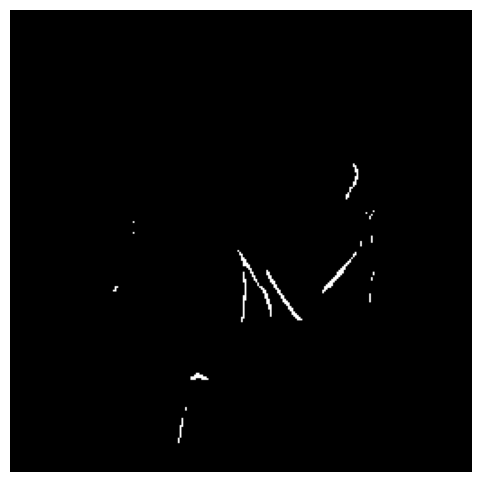

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(Image.open("results/prediction.png"))
plt.axis("off")

In [13]:
!head -60 read_palm.py

import os
import argparse
from tools import *
from model import *
from rectification import *
from detection import *
from classification import *
from measurement import *

def main(input):
    path_to_input_image = 'input/{}'.format(input)

    results_dir = './results'
    os.makedirs(results_dir, exist_ok=True)

    resize_value = 256
    path_to_clean_image = 'results/palm_without_background.jpg'
    path_to_warped_image = 'results/warped_palm.jpg'
    path_to_warped_image_clean = 'results/warped_palm_clean.jpg'
    path_to_warped_image_mini = 'results/warped_palm_mini.jpg'
    path_to_warped_image_clean_mini = 'results/warped_palm_clean_mini.jpg'
    path_to_palmline_image = 'results/palm_lines.png'
    path_to_model = 'checkpoint/checkpoint_aug_epoch70.pth'
    path_to_result = 'results/result.jpg'

    # 0. Preprocess image
    remove_background(path_to_input_image, path_to_clean_image)

    # 1. Palm image rectification
    warp_result = warp(path_to_input_image, path_to_warpe

In [14]:
!python read_palm.py --input hand1.jpg

Traceback (most recent call last):
  File "/kaggle/working/palmistry/code/read_palm.py", line 55, in <module>
    main(args.input)
  File "/kaggle/working/palmistry/code/read_palm.py", line 30, in main
    warp_result = warp(path_to_input_image, path_to_warped_image)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/palmistry/code/rectification.py", line 56, in warp
    warp_result = warp_image(path_to_input_image, path_to_warped_image)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/palmistry/code/rectification.py", line 34, in warp_image
    mp_hands = mp.solutions.hands
               ^^^^^^^^^^^^
AttributeError: module 'mediapipe' has no attribute 'solutions'


In [15]:
cp rectification.py rectification_backup.py

In [16]:
with open("rectification.py", "r") as f:
    print(f.read())

import numpy as np
import cv2
import mediapipe as mp

# code reference: https://google.github.io/mediapipe/solutions/hands.html

WARP_SUCCESS = 1

def warp_image(path_to_image, path_to_warped_image):
        # 7 landmark points (normalized)
    pts_index = list(range(21))
    pts_target_normalized = np.float32([[1-0.48203104734420776, 0.9063420295715332],
                                        [1-0.6043621301651001, 0.8119394183158875],
                                        [1-0.6763232946395874, 0.6790258884429932],
                                        [1-0.7340714335441589, 0.5716733932495117],
                                        [1-0.7896472215652466, 0.5098430514335632],
                                        [1-0.5655680298805237, 0.5117031931877136],
                                        [1-0.5979393720626831, 0.36575648188591003],
                                        [1-0.6135331392288208, 0.2713503837585449],
                                        [1-0.61964833

In [17]:
%%writefile rectification.py
import numpy as np
import cv2
import mediapipe as mp
import urllib.request

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

WARP_SUCCESS = 1

# --------------------------------------------------
# Download MediaPipe Hand Landmarker model
# --------------------------------------------------

MODEL_URL = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
MODEL_PATH = "hand_landmarker.task"

urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

# --------------------------------------------------
# Create detector
# --------------------------------------------------

base_options = python.BaseOptions(
    model_asset_path=MODEL_PATH
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1
)

detector = vision.HandLandmarker.create_from_options(options)
# --------------------------------------------------
# Detect landmarks (used by measurement.py)
# --------------------------------------------------

def detect_landmarks(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.flip(image, 1)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=image_rgb
    )

    detection_result = detector.detect(mp_image)

    if len(detection_result.hand_landmarks) == 0:
        return None

    return detection_result.hand_landmarks[0]

# --------------------------------------------------
# Warp Palm Image
# --------------------------------------------------

def warp_image(path_to_image, path_to_warped_image):

    pts_target_normalized = np.float32([
        [1-0.48203104734420776, 0.9063420295715332],
        [1-0.6043621301651001, 0.8119394183158875],
        [1-0.6763232946395874, 0.6790258884429932],
        [1-0.7340714335441589, 0.5716733932495117],
        [1-0.7896472215652466, 0.5098430514335632],
        [1-0.5655680298805237, 0.5117031931877136],
        [1-0.5979393720626831, 0.36575648188591003],
        [1-0.6135331392288208, 0.2713503837585449],
        [1-0.6196483373641968, 0.19251111149787903],
        [1-0.4928809702396393, 0.4982593059539795],
        [1-0.4899863600730896, 0.3213786780834198],
        [1-0.4894656836986542, 0.21283167600631714],
        [1-0.48334982991218567, 0.12900274991989136],
        [1-0.4258815348148346, 0.5180916786193848],
        [1-0.4033462107181549, 0.3581996262073517],
        [1-0.3938145041465759, 0.2616880536079407],
        [1-0.38608720898628235, 0.1775170862674713],
        [1-0.36368662118911743, 0.5642163157463074],
        [1-0.33553171157836914, 0.44737303256988525],
        [1-0.3209102153778076, 0.3749568462371826],
        [1-0.31213682889938354, 0.3026996850967407]
    ])

    # Read image
    image = cv2.imread(path_to_image)

    if image is None:
        return None

    # Mirror image exactly like original repository
    image = cv2.flip(image, 1)

    image_height, image_width = image.shape[:2]

    # Convert to MediaPipe Image
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=image_rgb
    )

    # Detect landmarks
    detection_result = detector.detect(mp_image)

    if len(detection_result.hand_landmarks) == 0:
        return None

    hand_landmarks = detection_result.hand_landmarks[0]

    # 21 landmark points
    pts = np.float32([
        [lm.x * image_width, lm.y * image_height]
        for lm in hand_landmarks
    ])

    pts_target = np.float32([
        [x * image_width, y * image_height]
        for x, y in pts_target_normalized
    ])

    # Homography
    M, mask = cv2.findHomography(
        pts,
        pts_target,
        cv2.RANSAC,
        5.0
    )

    if M is None:
        return None

    warped_image = cv2.warpPerspective(
        image,
        M,
        (image_width, image_height),
        borderMode=cv2.BORDER_REPLICATE
    )

    cv2.imwrite(
        path_to_warped_image,
        warped_image
    )

    return WARP_SUCCESS


def warp(path_to_input_image, path_to_warped_image):

    if path_to_input_image[-4:] in ["heic", "HEIC"]:
        path_to_input_image = path_to_input_image[:-4] + "jpg"

    warp_result = warp_image(
        path_to_input_image,
        path_to_warped_image
    )

    if warp_result is None:
        return None

    return WARP_SUCCESS

Overwriting rectification.py


In [18]:
!head -20 rectification.py

import numpy as np
import cv2
import mediapipe as mp
import urllib.request

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

WARP_SUCCESS = 1

# --------------------------------------------------
# Download MediaPipe Hand Landmarker model
# --------------------------------------------------

MODEL_URL = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
MODEL_PATH = "hand_landmarker.task"

urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

# --------------------------------------------------


In [19]:
!python read_palm.py --input hand1.jpg

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1784952498.404522     197 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784952498.419248     198 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784952498.524147     199 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
Traceback (most recent call last):
  File "/kaggle/working/palmistry/code/read_palm.py", line 55, in <module>
    main(args.input)
  File "/kaggle/working/palmistry/code/read_palm.py", line 43, in main
    lines = classify(path_to_palmline_image)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/palmistry/code/classification.py", line 359, in classify
 

In [20]:
!grep -n "skeletonize" classification.py

6:from skimage.morphology import skeletonize
316:            skel_img = cv2.cvtColor(skeletonize(img), cv2.COLOR_BGR2GRAY)
359:    skel_img = cv2.cvtColor(skeletonize(palmline_img), cv2.COLOR_BGR2GRAY)


In [21]:
with open("classification.py", "r") as f:
    print(f.read())

import os
import glob
import numpy as np
import cv2
from PIL import Image
from skimage.morphology import skeletonize
import mediapipe as mp

#########################################################################################
# Sketch of idea                                                                        #
# - Build a graph : nodes = end pt. + intersection pt.                                  #
#                  edges = line segments (save pixel coordinates with next direction)   #
# - Find all possible paths(lines) from graph : graph backtracking                      #
# - Find three lines nearest to each cluster centers in feature space                   #
#   Find cluster centers using k-means clustering (k=3)                                 #
#########################################################################################

# code reference: https://google.github.io/mediapipe/solutions/hands.html
# data reference: https://drive.google.com/file/d/1B4uj-b4RuUNkC

In [22]:
%%writefile classification.py

import os
import glob
import numpy as np
import cv2
from PIL import Image
from skimage.morphology import skeletonize
import mediapipe as mp

#########################################################################################
# Sketch of idea                                                                        #
# - Build a graph : nodes = end pt. + intersection pt.                                  #
#                  edges = line segments (save pixel coordinates with next direction)   #
# - Find all possible paths(lines) from graph : graph backtracking                      #
# - Find three lines nearest to each cluster centers in feature space                   #
#   Find cluster centers using k-means clustering (k=3)                                 #
#########################################################################################

# code reference: https://google.github.io/mediapipe/solutions/hands.html
# data reference: https://drive.google.com/file/d/1B4uj-b4RuUNkC_oeCsRkuih4rjuQ6tHH/view

### 0. Load Data ###

# PLSU folder should exist in advance
# rectify images in PLSU folder
# find homography matrix using original image
# then apply homography matrix to detected line image
# input is the number 'idx' from image{idx}.jpg(.png)
def rectify(idx):
    img_path = './PLSU/PLSU/'
    image = cv2.imread(img_path + 'img/image' + str(idx) +'.jpg')
    image_mask = cv2.imread(img_path + 'Mask/image' + str(idx) + '.png', cv2.IMREAD_GRAYSCALE)
    mp_hands = mp.solutions.hands

    # 7 landmark points (normalized)
    pts_index = list(range(21))
    pts_target_normalized = np.float32([[1-0.48203104734420776, 0.9063420295715332],
                                        [1-0.6043621301651001, 0.8119394183158875],
                                        [1-0.6763232946395874, 0.6790258884429932],
                                        [1-0.7340714335441589, 0.5716733932495117],
                                        [1-0.7896472215652466, 0.5098430514335632],
                                        [1-0.5655680298805237, 0.5117031931877136],
                                        [1-0.5979393720626831, 0.36575648188591003],
                                        [1-0.6135331392288208, 0.2713503837585449],
                                        [1-0.6196483373641968, 0.19251111149787903],
                                        [1-0.4928809702396393, 0.4982593059539795],
                                        [1-0.4899863600730896, 0.3213786780834198],
                                        [1-0.4894656836986542, 0.21283167600631714],
                                        [1-0.48334982991218567, 0.12900274991989136],
                                        [1-0.4258815348148346, 0.5180916786193848],
                                        [1-0.4033462107181549, 0.3581996262073517],
                                        [1-0.3938145041465759, 0.2616880536079407],
                                        [1-0.38608720898628235, 0.1775170862674713],
                                        [1-0.36368662118911743, 0.5642163157463074],
                                        [1-0.33553171157836914, 0.44737303256988525],
                                        [1-0.3209102153778076, 0.3749568462371826],
                                        [1-0.31213682889938354, 0.3026996850967407]])
    
    with mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5) as hands:
        results = hands.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        
        if results.multi_hand_landmarks == None: return np.zeros_like(image)
        image_height, image_width, _ = image.shape
        hand_landmarks = results.multi_hand_landmarks[0]
        pts = np.float32([[hand_landmarks.landmark[i].x*image_width,
                           hand_landmarks.landmark[i].y*image_height] for i in pts_index])
        pts_target = np.float32([[x*image_width, y*image_height] for x,y in pts_target_normalized])
        M, mask = cv2.findHomography(pts, pts_target, cv2.RANSAC,5.0)
        rectified_image = cv2.warpPerspective(image_mask, M, (image_width, image_height))
        pil_img = Image.fromarray(rectified_image)
        rectified_image = np.asarray(pil_img.resize((1024, 1024), resample=Image.NEAREST))
        return rectified_image

# load rectified data from PLSU to new folder
def load_data(num_data):
    # make directory
    data_path = './line_sample'
    result_path = './line_sample_result'
    path_list = [data_path, result_path]
    for path in path_list:
        os.makedirs(path, exist_ok=True)
        
    # count the current number of data
    cur_num_data = len(os.listdir(data_path))
    
    # load rectified data from PLSU data
    offset = 50
    img_path_list = [img_path for img_path in glob.glob('./PLSU/PLSU/Img/*')][offset+cur_num_data:offset+num_data]
    for i,img_path in enumerate(img_path_list):
        idx = img_path.split('image')[1].split('.')[0]
        rectified_image = rectify(idx)
        if np.sum(rectified_image)==0: continue
        cv2.imwrite('line_sample/image' + str(i+cur_num_data) + '.png', rectified_image)

### 1. Find possible lines ###

# connect seperated lines by gradient
# https://stackoverflow.com/questions/63727525/how-to-connect-broken-lines-that-cannot-be-connected-by-erosion-and-dilation
# https://stackoverflow.com/questions/43859750/how-to-connect-broken-lines-in-a-binary-image-using-python-opencv

# find all possible lines by graph backtracking
# lines_node : list of lines represented by nodes // ex. [[node0, ..., node3], ..., [node2, ..., node4]]
# temp : list of nodes up to now
# graph : node -> {adj. node -> line between two node} (dictionary type)
# visited_node : visited nodes up to now
# finished_node : visited nodes at least once
# node : current node
def backtrack(lines_node, temp, graph, visited_node, finished_node, node):
    end_pt = True
    for next_node in graph[node].keys():
        if not visited_node[next_node]:
            end_pt = False
            temp.append(next_node)
            visited_node[next_node] = True
            finished_node[next_node] = True
            backtrack(lines_node, temp, graph, visited_node, finished_node, next_node)
            del temp[-1]
            visited_node[next_node] = False
    # if there is no way to preceed, current node is the end node
    # add current line to the list
    if end_pt:
        line_node = []
        line_node.extend(temp)
        lines_node.append(line_node)

# find possible lines
# (1) build a graph
# (2) find all possible lines by graph backtracking
# (3) filter lines with length, direction criteria
def group(img):
    # (1) build a graph
    
    # (1)-1 find all nodes
    count = np.zeros(img.shape)
    nodes = []

    for j in range(1, img.shape[0] - 1):
        for i in range(1, img.shape[1] - 1):
            if img[j, i] == 0: continue
            count[j, i] = np.count_nonzero(img[j-1:j+2, i-1:i+2]) - 1
            if count[j, i] == 1 or count[j, i] >= 3:
                nodes.append((j, i))

    # sort nodes to traverse from upper-left to lower-right
    nodes.sort(key = lambda x : x[0]+x[1])
     
    # (1)-2 save all connections
    graph = dict()
    for node in nodes:
        graph[node] = dict()

    not_visited = np.ones(img.shape)
    for node in nodes:
        y,x = node
        not_visited[y, x] = 0
        around = np.multiply(count[y-1:y+2, x-1:x+2], not_visited[y-1:y+2, x-1:x+2])
        next_pos = np.transpose(np.nonzero(around))
        if next_pos.shape[0] == 0: continue
        for dy,dx in next_pos:
            y,x = node
            next_y = y + dy - 1
            next_x = x + dx - 1
            if dx == 0 or (dy == 0 and dx == 1):
                dy,dx = 2-dy,2-dx
            temp_line = [[y,x,0,0], [next_y,next_x,dy-1,dx-1]]
            if count[next_y, next_x] == 1 or count[next_y, next_x] >= 3:
                not_visited[next_y, next_x] = 1
                graph[tuple(temp_line[0][:2])][tuple(temp_line[-1][:2])] = temp_line
                temp_line_rev = list(reversed(temp_line))
                graph[tuple(temp_line[-1][:2])][tuple(temp_line[0][:2])] = temp_line_rev
                continue
        
            while(True):
                y,x = temp_line[-1][:2]
                not_visited[y, x] = 0
                around = np.multiply(count[y-1:y+2, x-1:x+2], not_visited[y-1:y+2, x-1:x+2])
                next_pos = np.transpose(np.nonzero(around))
                if next_pos.shape[0] == 0: break
                
                # update line
                next_y = y + next_pos[0][0] - 1
                next_x = x + next_pos[0][1] - 1
                dy,dx = next_y-y,next_x-x
                if dx == -1 or (dy == -1 and dx == 0):
                    dy,dx = -dy,-dx
                temp_line.append([next_y, next_x, dy, dx])
                not_visited[next_y, next_x] = 0
                
                # check end condition
                if count[next_y, next_x] == 1 or count[next_y, next_x] >= 3:
                    #if len(temp_line) > 10:
                    graph[tuple(temp_line[0][:2])][tuple(temp_line[-1][:2])] = temp_line
                    temp_line_rev = list(reversed(temp_line))
                    graph[tuple(temp_line[-1][:2])][tuple(temp_line[0][:2])] = temp_line_rev
                    not_visited[next_y, next_x] = 1
                    break
        not_visited[node[0], node[1]] = 1


    # (2) find all possible lines by graph backtracking
    lines_node = []
    visited_node = dict()
    finished_node = dict()
    for node in nodes:
        visited_node[node] = False
        finished_node[node] = False
    
    for node in nodes:
        if not finished_node[node]:
            temp = [node]
            visited_node[node] = True
            finished_node[node] = True
            backtrack(lines_node, temp, graph, visited_node, finished_node, node)
    
    # (3) filter lines with length, direction criteria
    lines = []
    for line_node in lines_node:
        num_node = len(line_node)
        if num_node == 1 : continue
        wrong = False
        line = []
        prev,cur = None,line_node[0]
        for i in range(1,num_node):
            nxt = line_node[i]
            # if the inner product of two connected line segments vectors is <0, discard it
            if i>1 and (cur[0]-prev[0])*(nxt[0]-cur[0])+(cur[1]-prev[1])*(nxt[1]-cur[1])<0:
                wrong = True
                break
            line.extend(graph[cur][nxt])
            prev,cur = cur,nxt
        # if the length is <10, discard it
        if wrong or len(line) < 10: continue
        lines.append(line)
    
    return lines

### 2. Choose three lines ###

# classify lines using l2 distance with centers in feature space
# remain at most 3 lines
def classify_lines(centers, lines, image_height, image_width):
    classified_lines = [None, None, None]
    line_idx = [None, None, None]
    nearest = [1e9, 1e9, 1e9]
    
    feature_list = np.empty((0,24))
    for line in lines:
        feature = extract_feature(line, image_height, image_width)
        feature_list = np.vstack((feature_list,feature))
    
    num_lines = len(lines)
    for i in range(3):
        center = centers[i]
        for j in range(num_lines):
            chosen = False
            for k in range(i-1):
                if line_idx[k]==j:
                    chosen = True
                    break
            if chosen: continue
            feature = feature_list[j]
            dist = np.linalg.norm(feature-center)
            if dist < nearest[i]:
                nearest[i] = dist
                classified_lines[i] = lines[j]
                line_idx[i] = j
    
    return classified_lines

### 3. Color each line ###

# color lines with BGR
def color(skel_img, lines):
    color_list = [[255,0,0], [0,255,0], [0,0,255]] # [B,G,R]
    
    num_lines = len(lines)
    colored_img = cv2.cvtColor(skel_img,cv2.COLOR_GRAY2RGB)
    for i in range(num_lines):
        line = lines[i]
        for y,x,_,_ in line:
            colored_img[y,x] = color_list[i]
            
    return colored_img


### Others ###

# extract feature from a line
def extract_feature(line, image_height, image_width):
    # feature = [min_y, min_x, max_y, max_x] + mean of direction info(dy,dx) * N intervals
    # => (2N+4)-dim
    image_size = np.array([image_height, image_width], dtype=np.float32)
    feature = np.append(np.min(line, axis=0)[:2]/image_size, np.max(line, axis=0)[:2]/image_size)
    feature *= 10
    N = 10
    step = len(line)//N
    for i in range(N):
        l = line[i*step:(i+1)*step]
        feature = np.append(feature, np.mean(l, axis=0)[2:])
    return feature
      

# find 3 cluster centers in feature space
# we can use pre-trained centers for testing
def get_cluster_centers(new_centers=False):
    if new_centers:
        # prepare good samples
        good = [12,104,193,212,220,249,256,295,304,396,402,487,698,908,992]
        for idx in good:
            rectified = rectify(idx)
            cv2.imwrite("good_sample/image"+str(idx)+".png",rectified)
        
        # put all data in feature space
        data = np.empty((0,24))
        for img_path in glob.glob("good_sample/*.png"):
            img = cv2.imread(img_path)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

            skel = skeletonize(binary > 0)
            skel = (skel.astype(np.uint8)) * 255
            skel_img = skel
            lines = group(skel_img)
            for line in lines:
                feature = extract_feature(line, 1024, 1024)
                data = np.vstack((data,feature))
        
        # k-means clustering (k=3)
        criteria = (cv2.TERM_CRITERIA_EPS|cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
        ret, label, centers = cv2.kmeans(data.astype(np.float32), 3, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
        
        # sort centers according to max_y
        centers = list(centers)
        centers.sort(key = lambda x : x[2])
    else:
        centers = [np.array([5.232849  , 4.881592  , 6.3223267 , 6.64093   , 0.8113839 ,
                            0.655735  , 0.82874316, 0.74796075, 0.7993417 , 0.8345605 ,
                            0.68143266, 0.90320605, 0.5769709 , 0.9721149 , 0.53258324,
                            0.98307294, 0.4804058 , 0.9829783 , 0.36796156, 0.99141085,
                            0.24345541, 0.99082345, 0.30017138, 0.9736235 ], dtype=np.float32),
                     np.array([5.645419  , 4.169626  , 7.126243  , 6.0026045 , 0.3532842 ,
                            0.928315  , 0.4692493 , 0.9680717 , 0.578683  , 0.9680221 ,
                            0.7227269 , 0.9454175 , 0.7741767 , 0.9495983 , 0.7802345 ,
                            0.89685285, 0.8743354 , 0.8478447 , 0.85625464, 0.82669544,
                            0.88459945, 0.8000444 , 0.8956431 , 0.74734426], dtype=np.float32),
                     np.array([5.755994  , 3.8910964 , 8.680631  , 5.3926454 , 0.4247846 ,
                            0.93111324, 0.6940754 , 0.9203782 , 0.8567455 , 0.767301  ,
                            0.9177662 , 0.6054738 , 0.9801044 , 0.47111732, 0.9812451 ,
                            0.34593108, 0.97122467, 0.28715244, 0.9036454 , 0.26124895,
                            0.8069528 , 0.25324377, 0.59989274, 0.32016128], dtype=np.float32)]
    return centers

def classify(path_to_palmline_image):
    # load (rectified) test data
    # num_data = 10
    # load_data(num_data)
    
    # get cluster centers
    centers = get_cluster_centers()

    palmline_img = cv2.imread(path_to_palmline_image)
    kernel = np.ones((3, 3), np.uint8)
    # dilated = cv2.dilate(palmline_img, kernel, iterations=3)
    # eroded = cv2.erode(dilated, kernel, iterations=3)
    gray = cv2.cvtColor(palmline_img, cv2.COLOR_BGR2GRAY)

    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    skel = skeletonize(binary > 0)
    skel = (skel.astype(np.uint8)) * 255
    skel_img = skel
    print("skel_img shape:", skel_img.shape)
    print("skel_img dtype:", skel_img.dtype)
    
    #cv2.imwrite('results/skel.jpg',skel_img)
    
    lines = group(skel_img)  # get candidate lines
    lines = classify_lines(centers, lines, palmline_img.shape[0], palmline_img.shape[1])  # choose 3 lines from candidates
    # colored_img = color(skel_img, classified_lines) # color 3 lines (RGB)

    return lines


Overwriting classification.py


In [23]:
!python read_palm.py --input hand1.jpg

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1784952509.494732     242 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784952509.507773     242 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784952509.616217     242 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
skel_img shape: (256, 256)
skel_img dtype: uint8
Traceback (most recent call last):
  File "/kaggle/working/palmistry/code/read_palm.py", line 55, in <module>
    main(args.input)
  File "/kaggle/working/palmistry/code/read_palm.py", line 46, in main
    im, contents = measure(path_to_warped_image_mini, lines)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
 

In [24]:
with open("measurement.py", "r") as f:
    print(f.read())

from PIL import Image, ImageDraw
import cv2
import mediapipe as mp

def measure(path_to_warped_image_mini, lines):
    heart_thres_x = 0
    head_thres_x = 0
    life_thres_y = 0

    mp_hands = mp.solutions.hands
    with mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5) as hands:
        image = cv2.flip(cv2.imread(path_to_warped_image_mini), 1)
        image_height, image_width, _ = image.shape

        results = hands.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        hand_landmarks = results.multi_hand_landmarks[0]

        zero = hand_landmarks.landmark[mp_hands.HandLandmark(0).value].y
        one = hand_landmarks.landmark[mp_hands.HandLandmark(1).value].y
        five = hand_landmarks.landmark[mp_hands.HandLandmark(5).value].x
        nine = hand_landmarks.landmark[mp_hands.HandLandmark(9).value].x
        thirteen = hand_landmarks.landmark[mp_hands.HandLandmark(13).value].x

        heart_thres_x = image_width * (1 - (nine + (five - nin

In [25]:
%%writefile measurement.py
from PIL import Image, ImageDraw
import cv2

from rectification import detect_landmarks


def measure(path_to_warped_image_mini, lines):

    heart_thres_x = 0
    head_thres_x = 0
    life_thres_y = 0

    image = cv2.flip(cv2.imread(path_to_warped_image_mini), 1)

    if image is None:
        return None, None

    image_height, image_width = image.shape[:2]

    landmarks = detect_landmarks(path_to_warped_image_mini)

    if landmarks is None:
        return None, None

    zero = landmarks[0].y
    one = landmarks[1].y
    five = landmarks[5].x
    nine = landmarks[9].x
    thirteen = landmarks[13].x

    heart_thres_x = image_width * (1 - (nine + (five - nine) * 2 / 5))
    head_thres_x = image_width * (1 - (thirteen + (nine - thirteen) / 3))
    life_thres_y = image_height * (one + (zero - one) / 3)

    im = Image.open(path_to_warped_image_mini)

    width = 3

    if (None in lines) or (len(lines) < 3):
        return None, None

    draw = ImageDraw.Draw(im)

    # ---------------- Heart Line ----------------

    heart_line = lines[0]

    heart_line_points = [tuple(reversed(l[:2])) for l in heart_line]

    heart_line_tip = heart_line_points[0]

    heart_content_1 = (
        "Love line governs all matters of the heart, "
        "including romance, friendship, and commitment."
    )

    if heart_line_tip[0] < heart_thres_x:
        heart_content_2 = (
            "Your Heart line is long, which means you will have "
            "long partnership with whom you love or care."
        )
    else:
        heart_content_2 = (
            "Your Heart line is short, which means you will meet "
            "various people and have a broad range of relationships "
            "throughout your life."
        )

    draw.line(heart_line_points, fill="red", width=width)

    # ---------------- Head Line ----------------

    head_line = lines[1]

    head_line_points = [tuple(reversed(l[:2])) for l in head_line]

    head_line_tip = head_line_points[-1]

    head_content_1 = (
        "Head line tells us about our intellectual "
        "curiosities and pursuits."
    )

    if head_line_tip[0] > head_thres_x:
        head_content_2 = (
            "Your Head line is long, which means you will explore "
            "a broad range of topics throughout your life."
        )
    else:
        head_content_2 = (
            "Your Head line is short, which means you will be "
            "fascinated by one topic and dig deep into it."
        )

    draw.line(head_line_points, fill="green", width=width)

    # ---------------- Life Line ----------------

    life_line = lines[2]

    life_line_points = [tuple(reversed(l[:2])) for l in life_line]

    life_line_tip = life_line_points[-1]

    life_content_1 = (
        "Life line reveals your experiences, vitality, and zest. "
        "Be careful, it has nothing to do with how long you will live!"
    )

    if life_line_tip[1] > life_thres_y:
        life_content_2 = (
            "Your Life line is long, which means you tend to solve "
            "problems with other people rather than by yourself."
        )
    else:
        life_content_2 = (
            "Your Life line is short, which means you are "
            "independent and autonomous."
        )

    draw.line(life_line_points, fill="blue", width=width)

    contents = [
        heart_content_1,
        heart_content_2,
        head_content_1,
        head_content_2,
        life_content_1,
        life_content_2,
    ]

    return im, contents

Overwriting measurement.py


In [26]:
!python read_palm.py --input hand1.jpg

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1784952520.326418     287 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784952520.339417     287 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784952520.433248     287 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
skel_img shape: (256, 256)
skel_img dtype: uint8
Exception ignored in: <function HandLandmarker.__del__ at 0x7f9748f9e5c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/mediapipe/tasks/python/vision/hand_landmarker.py", line 603, in __del__
  File "/usr/local/lib/python3.12/dist-packages/mediapipe/tasks/python/vision/hand_landmarker.py

In [27]:
import os

for root, dirs, files in os.walk("."):
    for f in files:
        if f.endswith((".jpg", ".png", ".jpeg")):
            print(os.path.join(root, f))

./input/hand1.jpg
./input/hand48.jpg
./input/hand6.jpg
./input/hand70.jpg
./results/warped_palm_clean.jpg
./results/warped_palm_mini.jpg
./results/palm_without_background.jpg
./results/palm_lines.png
./results/warped_palm_clean_mini.jpg
./results/result.jpg
./results/warped_palm.jpg
./results/prediction.png


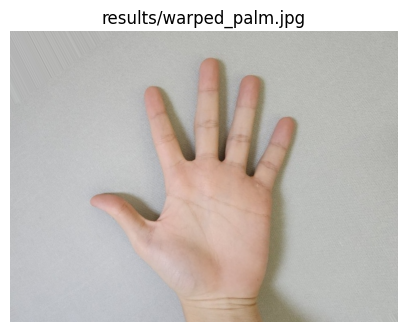

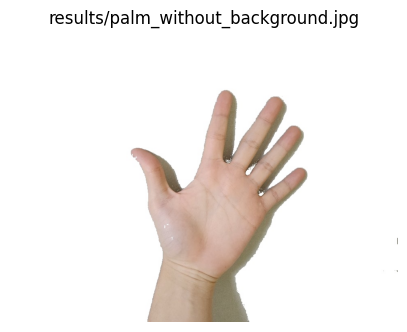

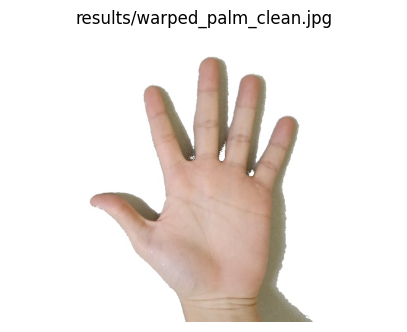

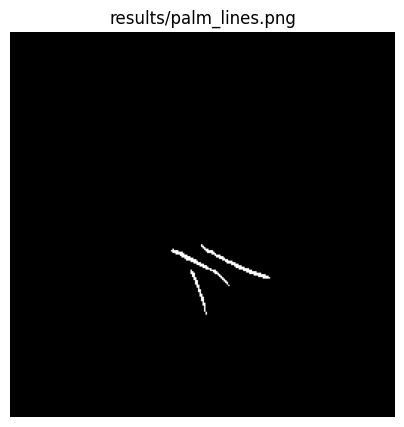

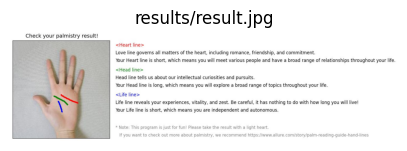

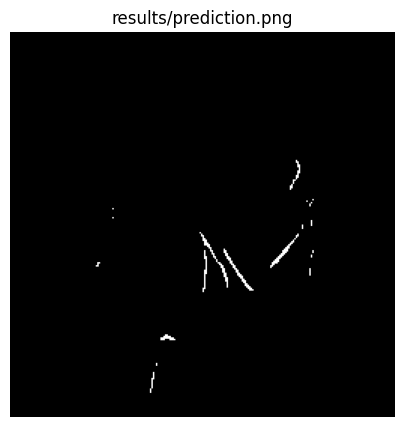

In [28]:
from PIL import Image
import matplotlib.pyplot as plt

files = [
    "results/warped_palm.jpg",
    "results/palm_without_background.jpg",
    "results/warped_palm_clean.jpg",
    "results/palm_lines.png",
    "results/result.jpg",
    "results/prediction.png"
]

for f in files:
    plt.figure(figsize=(5,5))
    plt.imshow(Image.open(f))
    plt.title(f)
    plt.axis("off")
    plt.show()

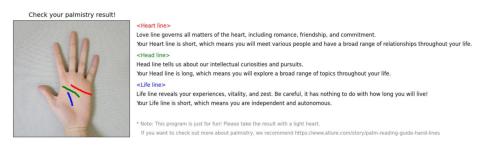

In [29]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("./results/result.jpg")

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

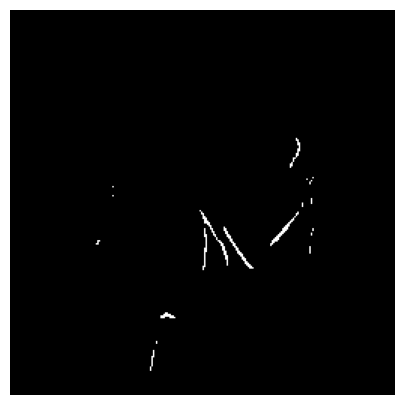

In [30]:
import cv2
import matplotlib.pyplot as plt

pred = cv2.imread("./results/prediction.png",0)

plt.figure(figsize=(5,5))
plt.imshow(pred,cmap="gray")
plt.axis("off")
plt.show()

In [31]:
!python read_palm.py --input hand1.jpg

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1784952531.896807     337 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784952531.909291     337 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784952532.002831     336 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
skel_img shape: (256, 256)
skel_img dtype: uint8
Exception ignored in: <function HandLandmarker.__del__ at 0x79c1e5592660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/mediapipe/tasks/python/vision/hand_landmarker.py", line 603, in __del__
  File "/usr/local/lib/python3.12/dist-packages/mediapipe/tasks/python/vision/hand_landmarker.py